<a href="https://colab.research.google.com/github/jahidurmahim/Machine_Learning_Laboratory/blob/main/Forward_Propogation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
iris = fetch_ucirepo(id=53)

# data (as pandas dataframes)
X = iris.data.features
y = iris.data.targets

# metadata
print(iris.metadata)

# variable information
print(iris.variables)


{'uci_id': 53, 'name': 'Iris', 'repository_url': 'https://archive.ics.uci.edu/dataset/53/iris', 'data_url': 'https://archive.ics.uci.edu/static/public/53/data.csv', 'abstract': 'A small classic dataset from Fisher, 1936. One of the earliest known datasets used for evaluating classification methods.\n', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 150, 'num_features': 4, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1936, 'last_updated': 'Tue Sep 12 2023', 'dataset_doi': '10.24432/C56C76', 'creators': ['R. A. Fisher'], 'intro_paper': {'ID': 191, 'type': 'NATIVE', 'title': 'The Iris data set: In search of the source of virginica', 'authors': 'A. Unwin, K. Kleinman', 'venue': 'Significance, 2021', 'year': 2021, 'journal': 'Significance, 2021', 'DOI': '1740-9713.01589', 'URL': 'https://www.semanticscholar.org

In [5]:
df = pd.concat([X, y], axis=1)
df.head()

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [7]:
df.shape

(150, 5)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal length  150 non-null    float64
 1   sepal width   150 non-null    float64
 2   petal length  150 non-null    float64
 3   petal width   150 non-null    float64
 4   class         150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [9]:
df.isna().sum().T

,0
sepal length,0
sepal width,0
petal length,0
petal width,0
class,0


In [10]:
df.duplicated().sum()

np.int64(3)

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sepal length,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width,150.0,3.054000,0.433594,2.0,2.8,3.00,3.3,4.4
petal length,150.0,3.758667,1.764420,1.0,1.6,4.35,5.1,6.9
petal width,150.0,1.198667,0.763161,0.1,0.3,1.30,1.8,2.5


In [12]:
outlier_summary = []

numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()

    if outlier_count > 0:
        outlier_summary.append({
            'feature': col,
            'Q1': Q1,
            'Q3': Q3,
            'lower_bound': lower,
            'upper_bound': upper,
            'outlier_count': outlier_count
        })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,feature,Q1,Q3,lower_bound,upper_bound,outlier_count
0,sepal width,2.8,3.3,2.05,4.05,4


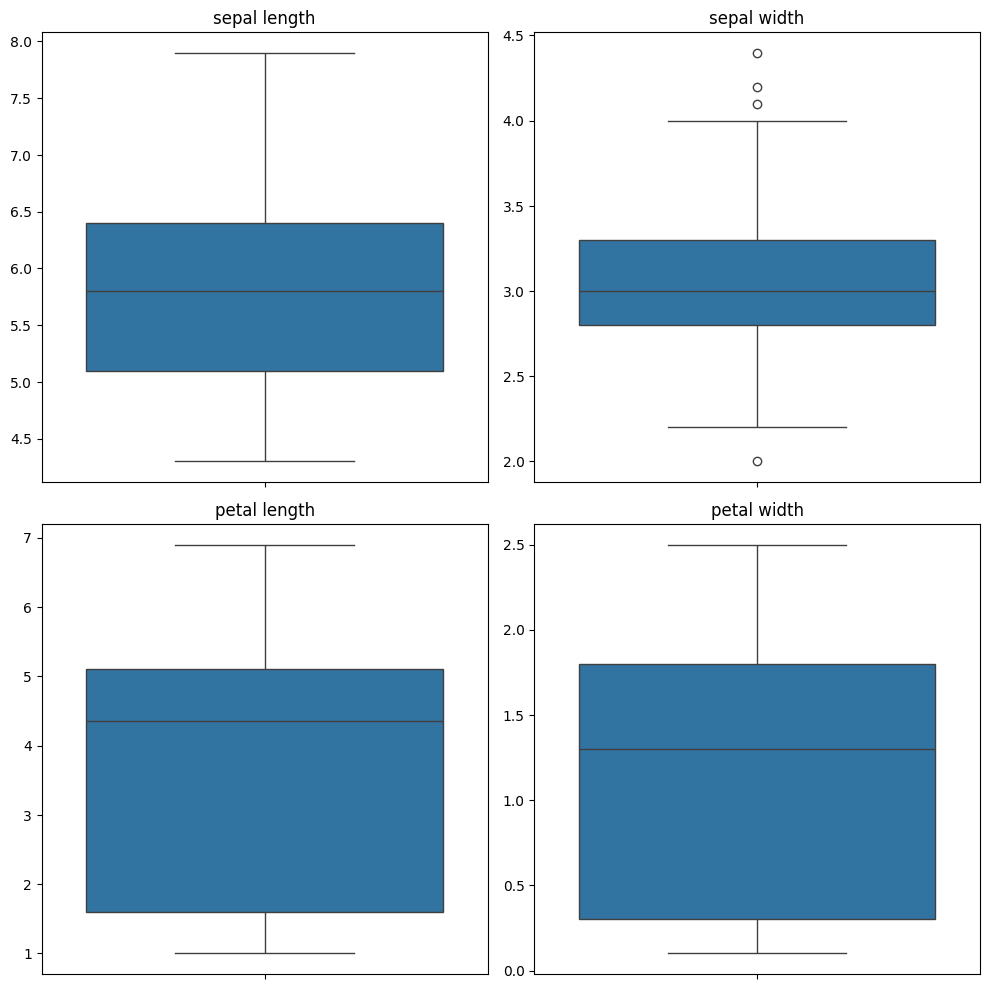

In [14]:
numeric_features = df.select_dtypes(include='number').columns.tolist()

rows = (len(numeric_features) + 1) // 2  # Adjust rows dynamically
cols = 2  # Set columns to 2 for better layout
fig, axes = plt.subplots(rows, cols, figsize=(10, 5 * rows))

axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.boxplot(y=df[feature], ax=axes[i])
    axes[i].set_title(feature)
    axes[i].set_ylabel('')

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [15]:
capped_summary = []

numeric_features = df.select_dtypes(include='number').columns.tolist()

for feature in numeric_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    capped_summary.append([feature, Q1, Q3, lower, upper, 0])

capped_df = pd.DataFrame(capped_summary, columns=['feature','Q1','Q3','lower_bound','upper_bound','outlier_count'])

display(capped_df)

,feature,Q1,Q3,lower_bound,upper_bound,outlier_count
0,sepal length,5.1,6.4,3.15,8.35,0
1,sepal width,2.8,3.3,2.05,4.05,0
2,petal length,1.6,5.1,-3.65,10.35,0
3,petal width,0.3,1.8,-1.95,4.05,0


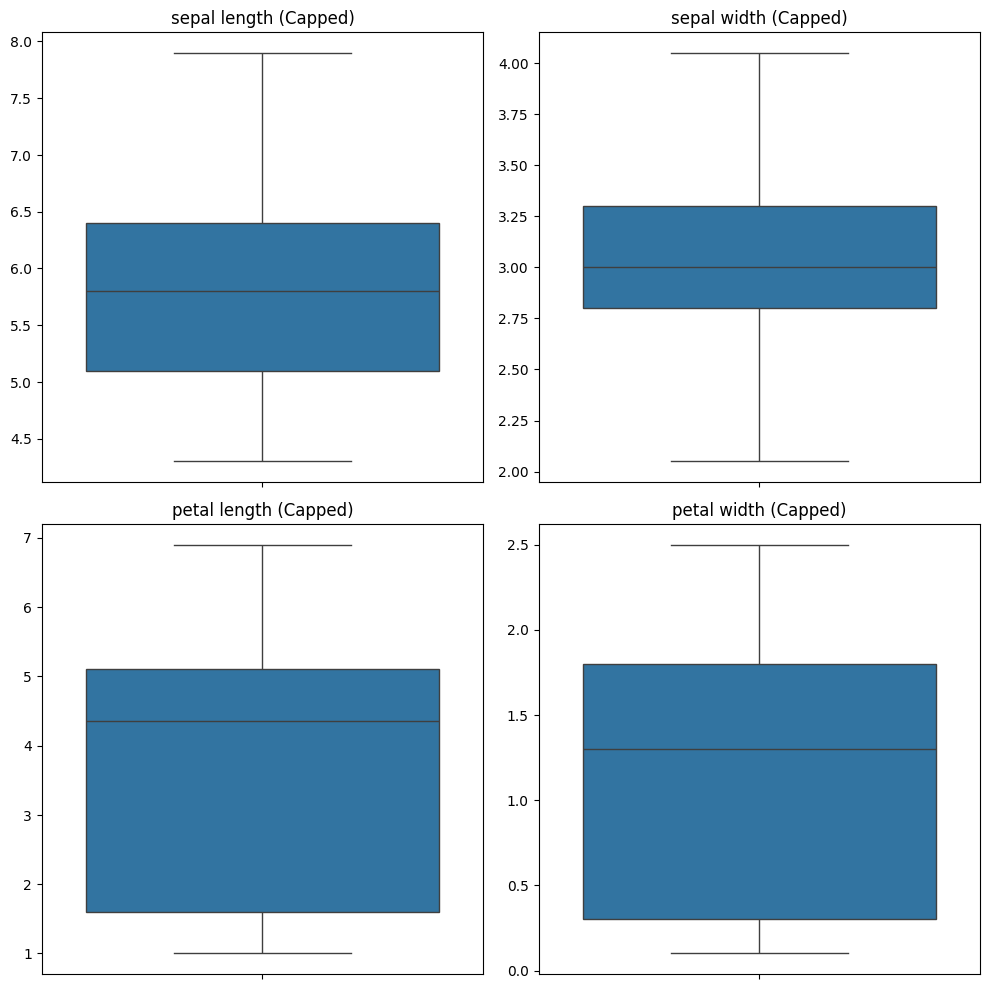

In [20]:
numeric_features_capped = df_capped.select_dtypes(include='number').columns.tolist()

rows_capped = (len(numeric_features_capped) + 1) // 2
cols_capped = 2
fig_capped, axes_capped = plt.subplots(rows_capped, cols_capped, figsize=(10, 5 * rows_capped))

axes_capped = axes_capped.flatten()

for i, feature in enumerate(numeric_features_capped):
    sns.boxplot(y=df_capped[feature], ax=axes_capped[i])
    axes_capped[i].set_title(f'{feature} (Capped)')
    axes_capped[i].set_ylabel('')

for j in range(i + 1, len(axes_capped)):
    fig_capped.delaxes(axes_capped[j])

plt.tight_layout()
plt.show()

In [21]:
X = df.drop("class", axis=1).values
y = df["class"].values.reshape(-1, 1)

print(X.shape)
print(y.shape)

(150, 4)
(150, 1)


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


In [27]:
import numpy as np
import matplotlib.pyplot as plt
# For reproducibility
np.random.seed(42)

In [29]:
def sigmoid(Z):
   """Sigmoid activation function: 1/(1 + e^(-Z))"""
   return 1 / (1 + np.exp(-Z))

def softmax(Z):
   """Softmax activation function for multi-class classification"""
   # Subtract max for numerical stability (prevents overflow)
   exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
   return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

In [31]:
class NeuralNetwork:
   def __init__(self, layer_dims, activations):
       """
       Initialize a neural network with specified layer dimensions and activations

       Parameters:
       - layer_dims: List of integers representing the number of neurons in each layer
                    (including input and output layers)
       - activations: List of activation functions for each layer (excluding input layer)
       """
       self.L = len(layer_dims) - 1  # Number of layers (excluding input layer)
       self.layer_dims = layer_dims
       self.activations = activations # Assuming this list only contains 'sigmoid' as per user's request
       self.parameters = {}

       # Initialize parameters (weights and biases)
       self.initialize_parameters()

   def initialize_parameters(self):
       """Initialize weights and biases with small random values"""
       for l in range(1, self.L + 1):
           # He initialization for weights - helps with training deep networks
           self.parameters[f'W{l}'] = np.random.randn(self.layer_dims[l], self.layer_dims[l-1]) * np.sqrt(2 / self.layer_dims[l-1])
           self.parameters[f'b{l}'] = np.zeros((self.layer_dims[l], 1))

   def forward_propagation(self, X):
       """
       Perform forward propagation through the network

       Parameters:
       - X: Input data (n_features, batch_size)

       Returns:
       - AL: Output of the network
       - caches: Dictionary containing all activations and pre-activations
       """
       caches = {}
       A = X  # Input layer activation
       caches['A0'] = X

       # Process through L-1 layers (hidden layers)
       for l in range(1, self.L):
           A_prev = A

           # Get weights and biases for current layer
           W = self.parameters[f'W{l}']
           b = self.parameters[f'b{l}']

           # Forward propagation for current layer
           Z = np.dot(W, A_prev) + b

           # Apply activation function - ONLY SIGMOID as requested
           A = sigmoid(Z)

           # Store values for backpropagation
           caches[f'Z{l}'] = Z
           caches[f'A{l}'] = A

       # Output layer (self.L)
       W = self.parameters[f'W{self.L}']
       b = self.parameters[f'b{self.L}']
       Z = np.dot(W, A) + b

       # Apply output activation function - ONLY SIGMOID as requested
       AL = sigmoid(Z)

       # Store output layer values
       caches[f'Z{self.L}'] = Z
       caches[f'A{self.L}'] = AL

       return AL, caches

In [33]:
input_dim = X_train.shape[1]
num_classes = len(np.unique(y_train)) # Determine number of unique classes from y_train
hidden_neurons = 10 # Using 10 hidden neurons as discussed
output_neurons = num_classes # For multi-class classification (3 classes for Iris)

layer_dims = [input_dim, hidden_neurons, output_neurons]
activations = ["sigmoid", "sigmoid"] # Explicitly using sigmoid for all layers

custom_nn = NeuralNetwork(layer_dims, activations)

In [36]:
input_dim = X_train.shape[1]
num_classes = len(np.unique(y_train)) # Determine number of unique classes from y_train
hidden_neurons = 10 # you can choose 5-50 depending on complexity
output_neurons = num_classes # For multi-class classification

layer_dims = [input_dim, hidden_neurons, output_neurons]
activations = ["sigmoid", "sigmoid"] # Use sigmoid for all layers as requested

In [34]:
X_sample = X_train[:5].T # Taking the first 5 examples and transposing to match (features, samples) format
output, caches = custom_nn.forward_propagation(X_sample)

print(f"Input shape: {X_sample.shape}")
print(f"Output shape: {output.shape}")
print(f"Output values (first example only):\n{output[:, 0].reshape(-1, 1)}") # Displaying output for the first example

Input shape: (4, 5)
Output shape: (3, 5)
Output values (first example only):
[[0.25091613]
 [0.58410527]
 [0.4705805 ]]


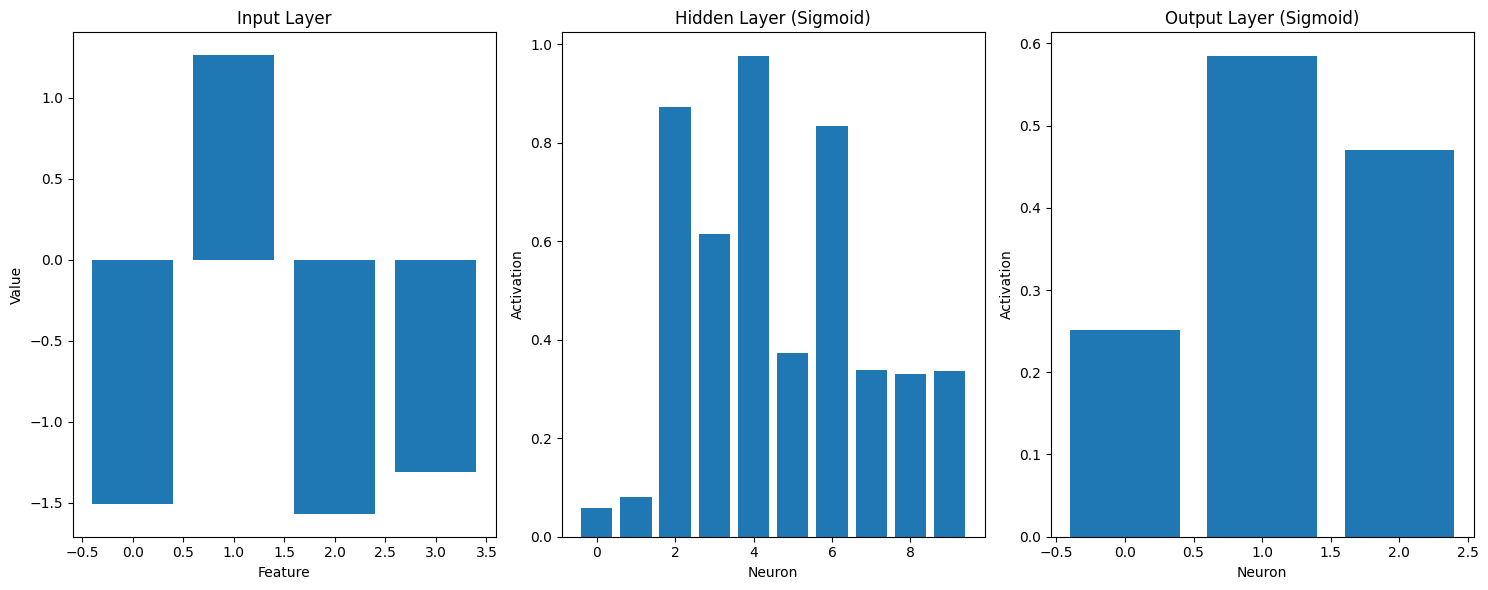

In [35]:
def visualize_activations(caches, example_idx=0):
    plt.figure(figsize=(15, 6))

    # Input Layer
    plt.subplot(1, 3, 1)
    plt.bar(range(caches['A0'].shape[0]), caches['A0'][:, example_idx])
    plt.title('Input Layer')
    plt.xlabel('Feature')
    plt.ylabel('Value')

    # Hidden Layer (A1 after input A0)
    plt.subplot(1, 3, 2)
    plt.bar(range(caches['A1'].shape[0]), caches['A1'][:, example_idx])
    plt.title('Hidden Layer (Sigmoid)') # Updated title
    plt.xlabel('Neuron')
    plt.ylabel('Activation')

    # Output Layer (A2 after A1)
    plt.subplot(1, 3, 3)
    plt.bar(range(caches['A2'].shape[0]), caches['A2'][:, example_idx])
    plt.title('Output Layer (Sigmoid)') # Updated title
    plt.xlabel('Neuron')
    plt.ylabel('Activation')

    plt.tight_layout()
    plt.show()

# Visualize the first example (example_idx=0 is default)
visualize_activations(caches)

In [37]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Reproducibility
tf.random.set_seed(42)

# Get input and output dimensions from previous steps
input_dim = X_train.shape[1]
num_classes = len(np.unique(y_train))

# Network for Iris dataset
tf_model = Sequential([
    Input(shape=(input_dim,)),       # Input features for Iris dataset
    Dense(10, activation='sigmoid'),  # Hidden layer with 10 neurons, using sigmoid activation
    Dense(num_classes, activation='softmax')  # Output layer (multi-class classification)
])

tf_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83 (332.00 B)

 Trainable params: 83 (332.00 B)

 Non-trainable params: 0 (0.00 B)

In [38]:
# Sample input data for Keras, using a subset of X_test
X_tf = X_test[:5]  # Using the first 5 examples from the test set

# Forward propagation in TensorFlow
tf_output = tf_model.predict(X_tf)

print(f"TensorFlow output shape: {tf_output.shape}")
print(f"TensorFlow output values:\n{tf_output}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
TensorFlow output shape: (5, 3)
TensorFlow output values:
[[0.42997545 0.22921696 0.34080756]
 [0.6059587  0.22144467 0.17259663]
 [0.3205355  0.20853943 0.470925  ]
 [0.45045716 0.22388457 0.3256583 ]
 [0.39354953 0.22653723 0.3799133 ]]


In [39]:
import torch
import torch.nn as tnn

# For reproducibility
torch.manual_seed(42)

# Get input and output dimensions from previous steps
input_dim = X_train.shape[1]
num_classes = len(np.unique(y_train))

class IrisNN(tnn.Module):
    def __init__(self):
        super(IrisNN, self).__init__()
        self.hidden = tnn.Linear(input_dim, 10)  # Input features, 10 hidden neurons
        self.sigmoid_activation = tnn.Sigmoid()  # Use sigmoid for hidden layer
        self.output = tnn.Linear(10, num_classes)   # Output neurons (multi-class classification)
        self.softmax_activation = tnn.Softmax(dim=1) # Softmax for multi-class output probabilities

    def forward(self, x):
        x = self.sigmoid_activation(self.hidden(x))
        x = self.softmax_activation(self.output(x))
        return x

# Instantiate the model
torch_model = IrisNN()
print(torch_model)

IrisNN(
  (hidden): Linear(in_features=4, out_features=10, bias=True)
  (sigmoid_activation): Sigmoid()
  (output): Linear(in_features=10, out_features=3, bias=True)
  (softmax_activation): Softmax(dim=1)
)


In [40]:
# Convert your numpy data to PyTorch tensors for the forward pass
X_torch = torch.tensor(X_train[:5], dtype=torch.float32) # Using the first 5 examples

# Forward propagation
torch_output = torch_model(X_torch)

print(f"PyTorch output shape: {torch_output.shape}")
print(f"PyTorch output values:\n{torch_output}")

PyTorch output shape: torch.Size([5, 3])
PyTorch output values:
tensor([[0.3340, 0.2597, 0.4063],
        [0.3063, 0.2349, 0.4588],
        [0.2955, 0.2244, 0.4801],
        [0.3358, 0.2577, 0.4065],
        [0.3434, 0.2637, 0.3928]], grad_fn=<SoftmaxBackward0>)


In [41]:
# Take a small sample for demonstration, consistent with previous steps
X_torch_sample = torch.tensor(X_train[:5], dtype=torch.float32)

with torch.no_grad():
    # Get raw output from hidden layer, then apply sigmoid activation
    hidden_output_raw = torch_model.hidden(X_torch_sample)
    hidden_act = torch_model.sigmoid_activation(hidden_output_raw)

    # Get raw output from output layer, then apply softmax activation
    output_output_raw = torch_model.output(hidden_act)
    output_act = torch_model.softmax_activation(output_output_raw)

print("Hidden layer activations (first sample only):\n", hidden_act[0])
print("Output layer probabilities (first sample only):\n", output_act[0])

Hidden layer activations (first sample only):
 tensor([0.4167, 0.5382, 0.1517, 0.4231, 0.5001, 0.4844, 0.7700, 0.3195, 0.4077,
        0.5522])
Output layer probabilities (first sample only):
 tensor([0.3340, 0.2597, 0.4063])


In [42]:
# Use a small, consistent sample size for comparison
sample_size = 5

# NumPy input (transpose to match custom_nn format: features x samples)
X_np_full = X_train[:sample_size].T

# TensorFlow input (samples x features)
X_tf_full = X_train[:sample_size]

# PyTorch input (samples x features)
X_torch_full = torch.tensor(X_train[:sample_size], dtype=torch.float32)

print(f"NumPy input shape (features, samples): {X_np_full.shape}")
print(f"TensorFlow input shape (samples, features): {X_tf_full.shape}")
print(f"PyTorch input shape (samples, features): {X_torch_full.shape}")

NumPy input shape (features, samples): (4, 5)
TensorFlow input shape (samples, features): (5, 4)
PyTorch input shape (samples, features): torch.Size([5, 4])


In [43]:
# NumPy output
output_np, caches_np = custom_nn.forward_propagation(X_np_full)

# TensorFlow output
tf_output_full = tf_model.predict(X_tf_full, verbose=0)

# PyTorch output
torch_output_full = torch_model(X_torch_full)

print("Forward propagation completed for all models.")

Forward propagation completed for all models.


In [45]:
print("\nComparison of implementations:")
print(f"NumPy output shape: {output.shape}")
print(f"TensorFlow output shape: {tf_output.shape}")
print(f"PyTorch output shape: {torch_output.shape}")


Comparison of implementations:
NumPy output shape: (3, 5)
TensorFlow output shape: (5, 3)
PyTorch output shape: torch.Size([5, 3])
